In [2]:
# import all the libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('Flight_Booking.csv')

In [4]:
df

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  str    
 2   flight            300153 non-null  str    
 3   source_city       300153 non-null  str    
 4   departure_time    300153 non-null  str    
 5   stops             300153 non-null  str    
 6   arrival_time      300153 non-null  str    
 7   destination_city  300153 non-null  str    
 8   class             300153 non-null  str    
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), str(8)
memory usage: 42.9 MB


In [6]:
df.drop(columns=['Unnamed: 0'], inplace=True)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  str    
 1   flight            300153 non-null  str    
 2   source_city       300153 non-null  str    
 3   departure_time    300153 non-null  str    
 4   stops             300153 non-null  str    
 5   arrival_time      300153 non-null  str    
 6   destination_city  300153 non-null  str    
 7   class             300153 non-null  str    
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 40.6 MB


In [8]:
df.isnull().sum()

airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

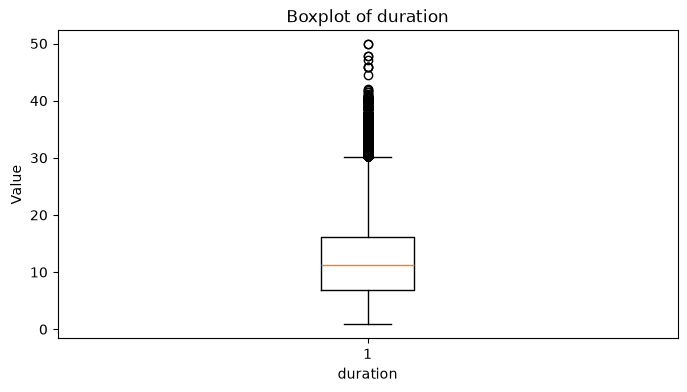

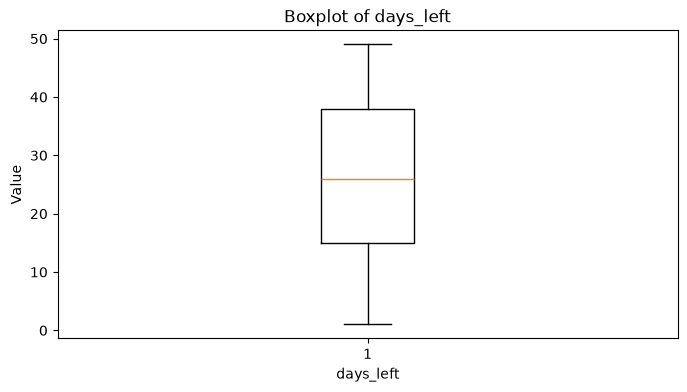

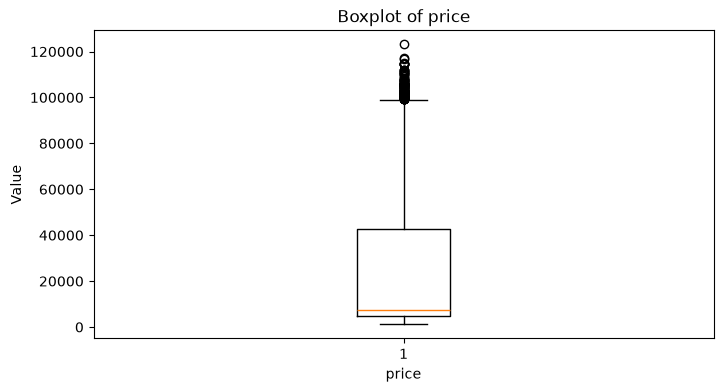

In [10]:
import matplotlib.pyplot as plt

num_cols = df.select_dtypes(include='number').columns

for i in num_cols:
    plt.figure(figsize=(8, 4))
    plt.boxplot(df[i].dropna())
    plt.xlabel(i)
    plt.ylabel('Value')
    plt.title(f'Boxplot of {i}')
    plt.show()

In [11]:
# drop the flight column

df.drop('flight', axis=1, inplace=True)

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  str    
 1   source_city       300153 non-null  str    
 2   departure_time    300153 non-null  str    
 3   stops             300153 non-null  str    
 4   arrival_time      300153 non-null  str    
 5   destination_city  300153 non-null  str    
 6   class             300153 non-null  str    
 7   duration          300153 non-null  float64
 8   days_left         300153 non-null  int64  
 9   price             300153 non-null  int64  
dtypes: float64(1), int64(2), str(7)
memory usage: 36.6 MB


In [13]:
# get the unique in stops col

df['stops'].unique()

<ArrowStringArray>
['zero', 'one', 'two_or_more']
Length: 3, dtype: str

In [15]:
# convert stops to numerical
# zero: 0
# one: 1
# two or more: 2

df['stops'] = df['stops'].replace({
    'zero':0,
    'one':1,
    'two_or_more':2
})


In [16]:
# make a dummy data for airline,source_city,departure_time, arrival_time,destination_city, class

categorical_col = ['airline','source_city','departure_time','arrival_time','destination_city','class']
df = pd.get_dummies(df,columns=categorical_col, drop_first=True)

In [17]:
df

,stops,duration,days_left,price,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,airline_Vistara,source_city_Chennai,...,arrival_time_Evening,arrival_time_Late_Night,arrival_time_Morning,arrival_time_Night,destination_city_Chennai,destination_city_Delhi,destination_city_Hyderabad,destination_city_Kolkata,destination_city_Mumbai,class_Economy
0,0,2.17,1,5953,False,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,True
1,0,2.33,1,5953,False,False,False,True,False,False,...,False,False,True,False,False,False,False,False,True,True
2,0,2.17,1,5956,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,True
3,0,2.25,1,5955,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,True,True
4,0,2.33,1,5955,False,False,False,False,True,False,...,False,False,True,False,False,False,False,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
300148,1,10.08,49,69265,False,False,False,False,True,True,...,True,False,False,False,False,False,True,False,False,False
300149,1,10.42,49,77105,False,False,False,False,True,True,...,False,False,False,True,False,False,True,False,False,False
300150,1,13.83,49,79099,False,False,False,False,True,True,...,False,False,False,True,False,False,True,False,False,False
300151,1,10.00,49,81585,False,False,False,False,True,True,...,True,False,False,False,False,False,True,False,False,False


In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 30 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   stops                         300153 non-null  object 
 1   duration                      300153 non-null  float64
 2   days_left                     300153 non-null  int64  
 3   price                         300153 non-null  int64  
 4   airline_Air_India             300153 non-null  bool   
 5   airline_GO_FIRST              300153 non-null  bool   
 6   airline_Indigo                300153 non-null  bool   
 7   airline_SpiceJet              300153 non-null  bool   
 8   airline_Vistara               300153 non-null  bool   
 9   source_city_Chennai           300153 non-null  bool   
 10  source_city_Delhi             300153 non-null  bool   
 11  source_city_Hyderabad         300153 non-null  bool   
 12  source_city_Kolkata           300153 non-null  bool   


In [19]:
# write a code to apply VIF exclude the object and target



from statsmodels.stats.outliers_influence import variance_inflation_factor

In [20]:
col_list = []

for i in df.columns:
  if(df[i].dtype!='object') and (i!='price'):
    col_list.append(i)

x = df[col_list]
x = x.astype(int)

vif_data = pd.DataFrame()
vif_data['Features'] = x.columns
vif_data['VIF Score'] = [variance_inflation_factor(x.values,i) for i in range(len(x.columns))]

In [21]:
vif_data

,Features,VIF Score
0,duration,4.927731
1,days_left,4.350982
2,airline_Air_India,5.045846
3,airline_GO_FIRST,1.979037
4,airline_Indigo,2.788941
5,airline_SpiceJet,1.445887
6,airline_Vistara,7.008753
7,source_city_Chennai,1.723238
8,source_city_Delhi,2.082977
9,source_city_Hyderabad,1.765531


In [22]:
x = df.drop('price', axis=1)
y = df['price']

In [23]:
x

,stops,duration,days_left,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,airline_Vistara,source_city_Chennai,source_city_Delhi,...,arrival_time_Evening,arrival_time_Late_Night,arrival_time_Morning,arrival_time_Night,destination_city_Chennai,destination_city_Delhi,destination_city_Hyderabad,destination_city_Kolkata,destination_city_Mumbai,class_Economy
0,0,2.17,1,False,False,False,True,False,False,True,...,False,False,False,True,False,False,False,False,True,True
1,0,2.33,1,False,False,False,True,False,False,True,...,False,False,True,False,False,False,False,False,True,True
2,0,2.17,1,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,True,True
3,0,2.25,1,False,False,False,False,True,False,True,...,False,False,False,False,False,False,False,False,True,True
4,0,2.33,1,False,False,False,False,True,False,True,...,False,False,True,False,False,False,False,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
300148,1,10.08,49,False,False,False,False,True,True,False,...,True,False,False,False,False,False,True,False,False,False
300149,1,10.42,49,False,False,False,False,True,True,False,...,False,False,False,True,False,False,True,False,False,False
300150,1,13.83,49,False,False,False,False,True,True,False,...,False,False,False,True,False,False,True,False,False,False
300151,1,10.00,49,False,False,False,False,True,True,False,...,True,False,False,False,False,False,True,False,False,False


In [24]:
y

0          5953
1          5953
2          5956
3          5955
4          5955
          ...  
300148    69265
300149    77105
300150    79099
300151    81585
300152    81585
Name: price, Length: 300153, dtype: int64

In [25]:
from sklearn.model_selection import train_test_split

In [26]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)

In [27]:
from sklearn.preprocessing import StandardScaler

In [28]:
sc = StandardScaler()

In [29]:
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [30]:
from sklearn.linear_model import LinearRegression

In [31]:
lr = LinearRegression()

In [32]:
lr.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](29,)","[ 2253.48, 608.01, -1745.81,..., 488.68, 22.42,-20915.41]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.089e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,29
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(29)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](29,)","[722.37,646.8 ,624.99,...,199.64,191.4 ,128.02]"


In [33]:

y_pred = lr.predict(x_test)

In [34]:
from sklearn.metrics import *

In [35]:
r2_score(y_test,y_pred)

0.9099031138535913